In [32]:
import pandas as pd

departments = pd.read_csv("2026-ASA-DataFest-Data-Files\departments.csv")
encounters = pd.read_csv("2026-ASA-DataFest-Data-Files\encounters.csv")
diagnosis = pd.read_csv("2026-ASA-DataFest-Data-Files\diagnosis.csv")
storm_data = pd.read_csv("2026-ASA-DataFest-Data-Files\storm_data_search_results.csv")

<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:4: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:4: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not w

In [33]:
storm_data = pd.read_csv("2026-ASA-DataFest-Data-Files\storm_data_search_results.csv")
storm_data["CZ_NAME_STR"] = storm_data["CZ_NAME_STR"].str[:-4]

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\owner\AppData\Local\Temp\ipykernel_7136\4093264494.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  storm_data = pd.read_csv("2026-ASA-DataFest-Data-Files\storm_data_search_results.csv")


In [34]:
kansas_counties = [
    'ALLEN', 'ANDERSON', 'ATCHISON', 'BARBER', 'BARTON', 'BOURBON', 'BROWN',
    'BUTLER', 'CHASE', 'CHAUTAUQUA', 'CHEROKEE', 'CHEYENNE', 'CLARK', 'CLAY',
    'CLOUD', 'COFFEY', 'COMANCHE', 'COWLEY', 'CRAWFORD', 'DECATUR', 'DICKINSON',
    'DONIPHAN', 'DOUGLAS', 'EDWARDS', 'ELK', 'ELLIS', 'ELLSWORTH', 'FINNEY',
    'FORD', 'FRANKLIN', 'GEARY', 'GOVE', 'GRAHAM', 'GRANT', 'GRAY', 'GREELEY',
    'GREENWOOD', 'HAMILTON', 'HARPER', 'HARVEY', 'HASKELL', 'HODGEMAN', 'JACKSON',
    'JEFFERSON', 'JEWELL', 'JOHNSON', 'KEARNY', 'KINGMAN', 'KIOWA', 'LABETTE',
    'LANE', 'LEAVENWORTH', 'LINCOLN', 'LINN', 'LOGAN', 'LYON', 'MARION', 'MARSHALL',
    'MCPHERSON', 'MEADE', 'MIAMI', 'MITCHELL', 'MONTGOMERY', 'MORRIS', 'MORTON',
    'NEMAHA', 'NEOSHO', 'NESS', 'NORTON', 'OSAGE', 'OSBORNE', 'OTTAWA', 'PAWNEE',
    'PHILLIPS', 'POTTAWATOMIE', 'PRATT', 'RAWLINS', 'RENO', 'REPUBLIC', 'RICE',
    'RILEY', 'ROOKS', 'RUSH', 'RUSSELL', 'SALINE', 'SCOTT', 'SEDGWICK', 'SEWARD',
    'SHAWNEE', 'SHERIDAN', 'SHERMAN', 'SMITH', 'STAFFORD', 'STANTON', 'STEVENS',
    'SUMNER', 'THOMAS', 'TREGO', 'WABAUNSEE', 'WALLACE', 'WASHINGTON', 'WICHITA',
    'WILSON', 'WOODSON', 'WYANDOTTE'
]

departments = departments[departments["County"].isin(kansas_counties)]

In [35]:
storm_list = sorted(storm_data["CZ_NAME_STR"].dropna().unique().tolist())

health_list = sorted(departments["County"].dropna().unique().tolist())


In [36]:
storm_data = storm_data.rename(columns={"CZ_NAME_STR":"County"})
ef_to_impact = {
    'EFU': 1,
    'EF0': 2,
    'EF1': 3,
    'EF2': 4,
    'EF3': 5,
    'EF4': 6,
    'EF5': 7
}

# Create new column 'Impact'
storm_data['Impact'] = storm_data["TOR_F_SCALE"].map(ef_to_impact)

In [37]:
merged_df = pd.merge(departments, storm_data, on='County', how='left')


In [38]:
merged_health = pd.merge(encounters, departments, on='DepartmentKey', how='left')

In [39]:
incident_number = (
    merged_health
    .groupby(["County", "Date"])
    .size()
    .reset_index(name="patient_count")
)

In [40]:

# Ensure date columns are datetime
storm_data["BEGIN_DATE"] = pd.to_datetime(storm_data["BEGIN_DATE"])
storm_data["END_DATE"] = pd.to_datetime(storm_data["END_DATE"])

expanded_rows = []

for _, row in storm_data.iterrows():
    county = row["County"]
    impact = row["Impact"]
    start = row["BEGIN_DATE"]
    end = row["END_DATE"]

    # --- DURING STORM ---
    during_dates = pd.date_range(start=start, end=end, freq="D")
    for d in during_dates:
        expanded_rows.append({
            "Date": d,
            "Impact": impact,
            "period": "during",
            "County": county
        })

    # --- AFTER STORM (7 days) ---
    after_dates = pd.date_range(
        start=end + pd.Timedelta(days=1),
        end=end + pd.Timedelta(days=7),
        freq="D"
    )
    for d in after_dates:
        expanded_rows.append({
            "Date": d,
            "Impact": impact,
            "period": "after",
            "County": county
        })


storm_days = pd.DataFrame(expanded_rows)

storm_days = storm_days.sort_values(["County", "Date"]).reset_index(drop=True)

incident_number

,County,Date,patient_count
0,DOUGLAS,01/02/24,12
1,DOUGLAS,01/03/22,6
2,DOUGLAS,01/03/23,1
3,DOUGLAS,01/03/24,6
4,DOUGLAS,01/04/24,4
...,...,...,...
8891,SHAWNEE,12/30/25,6514
8892,SHAWNEE,12/31/22,736
8893,SHAWNEE,12/31/23,734
8894,SHAWNEE,12/31/24,5885


In [41]:
incident_number["Date"] = pd.to_datetime(incident_number["Date"])
storm_days["Date"] = pd.to_datetime(storm_days["Date"])

# Left merge
merged_data = incident_number.merge(
    storm_days,
    how="left",
    on=["County", "Date"]
)

# Fill missing storm values
merged_data["Impact"] = merged_data["Impact"].fillna(0)

# Optional: fill missing period too
merged_data["period"] = merged_data["period"].fillna("none")

merged_data

C:\Users\owner\AppData\Local\Temp\ipykernel_7136\4242447553.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  incident_number["Date"] = pd.to_datetime(incident_number["Date"])


,County,Date,patient_count,Impact,period
0,DOUGLAS,2024-01-02,12,0.0,none
1,DOUGLAS,2022-01-03,6,0.0,none
2,DOUGLAS,2023-01-03,1,0.0,none
3,DOUGLAS,2024-01-03,6,0.0,none
4,DOUGLAS,2024-01-04,4,0.0,none
...,...,...,...,...,...
8920,SHAWNEE,2025-12-30,6514,0.0,none
8921,SHAWNEE,2022-12-31,736,0.0,none
8922,SHAWNEE,2023-12-31,734,0.0,none
8923,SHAWNEE,2024-12-31,5885,0.0,none


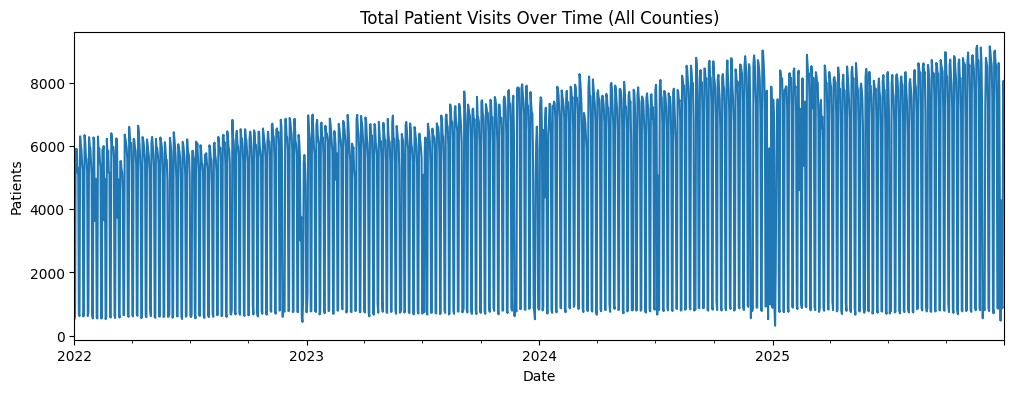

In [42]:
import matplotlib.pyplot as plt

daily_total = merged_data.groupby("Date")["patient_count"].sum()

plt.figure(figsize=(12,4))
daily_total.plot()
plt.title("Total Patient Visits Over Time (All Counties)")
plt.xlabel("Date")
plt.ylabel("Patients")
plt.show()

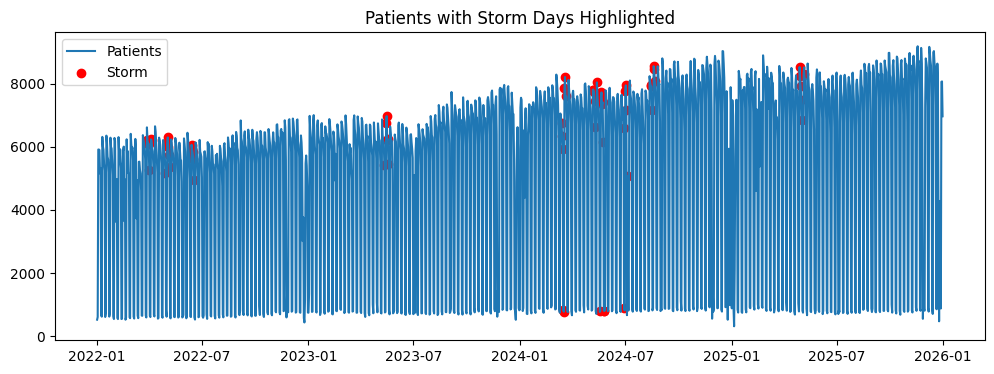

In [43]:
storm_days = merged_data.groupby("Date")["Impact"].max()

plt.figure(figsize=(12,4))
plt.plot(daily_total.index, daily_total.values, label="Patients")

# mark storm days
storm_dates = storm_days[storm_days > 0].index
plt.scatter(storm_dates, daily_total.loc[storm_dates], color="red", label="Storm")

plt.title("Patients with Storm Days Highlighted")
plt.legend()
plt.show()

In [44]:
import plotly.graph_objects as go
import nbformat
daily_total = merged_data.groupby("Date")["patient_count"].sum()
storm_info = merged_data.groupby("Date")["Impact"].max()
storm_dates = storm_info[storm_info > 0].index

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily_total.index,
    y=daily_total.values,
    mode="lines",
    name="Patients"
))

fig.add_trace(go.Scatter(
    x=storm_dates,
    y=daily_total.loc[storm_dates],
    mode="markers",
    name="Storm",
    marker=dict(color="red", size=8),
    text=[f"Impact: {storm_info.loc[d]}" for d in storm_dates],
    hovertemplate="Date: %{x}<br>Patients: %{y}<br>%{text}<extra></extra>"
))

fig.update_layout(
    title="Patients with Storm Days Highlighted",
    xaxis_title="Date",
    yaxis_title="Patients"
)

fig.show()

In [45]:
weekly = merged_data.groupby("Date")["patient_count"].sum().rolling(7).mean()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=weekly.index,
    y=weekly.values,
    mode="lines",
    name="7-day avg patients"
))

# storm markers
storm_info = merged_data.groupby("Date")["Impact"].max()
storm_dates = storm_info[storm_info > 0].index

fig.add_trace(go.Scatter(
    x=storm_dates,
    y=weekly.loc[storm_dates],
    mode="markers",
    marker=dict(color="red", size=8),
    text=[f"Impact: {storm_info.loc[d]}" for d in storm_dates],
    hovertemplate="Date: %{x}<br>%{text}<extra></extra>"
))

fig.update_layout(title="Smoothed Patients vs Storms")
fig.show()

In [46]:
event_rows = []

storm_days = merged_data[merged_data["Impact"] > 0][["County", "Date"]]

for _, row in storm_days.iterrows():
    county = row["County"]
    storm_date = row["Date"]

    subset = merged_data[merged_data["County"] == county]

    for lag in range(-15, 15):  # 3 days before, 7 after
        day = storm_date + pd.Timedelta(days=lag)

        value = subset.loc[subset["Date"] == day, "patient_count"]

        if not value.empty:
            event_rows.append({
                "lag": lag,
                "patient_count": value.values[0]
            })

event_df = pd.DataFrame(event_rows)
event_avg = event_df.groupby("lag")["patient_count"].mean()
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=event_avg.index,
    y=event_avg.values,
    mode="lines+markers"
))

fig.add_vline(x=0, line_dash="dash", line_color="red")

fig.update_layout(
    title="Average Patient Response Around Storms",
    xaxis_title="Days Relative to Storm",
    yaxis_title="Patients"
)

fig.show()

In [47]:
merged_data["day_of_week"] = merged_data["Date"].dt.dayofweek

merged_data["patient_dow_norm"] = (
    merged_data.groupby(["County", "day_of_week"])["patient_count"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

event_rows = []

# Unique storm events (avoid duplicates)
storm_days = (
    merged_data[merged_data["Impact"] > 1][["County", "Date"]]
    .drop_duplicates()
)

for _, row in storm_days.iterrows():
    county = row["County"]
    storm_date = row["Date"]

    subset = merged_data[merged_data["County"] == county]

    for lag in range(-7, 7):  # widen window if you like
        day = storm_date + pd.Timedelta(days=lag)

        value = subset.loc[subset["Date"] == day, "patient_dow_norm"]

        if not value.empty:
            event_rows.append({
                "lag": lag,
                "value": value.values[0]
            })

event_df = pd.DataFrame(event_rows)

# Average across events
event_avg = event_df.groupby("lag")["value"].mean()

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=event_avg.index,
    y=event_avg.values,
    mode="lines+markers",
    name="Normalised response"
))

# Storm day marker
fig.add_vline(x=0, line_dash="dash", line_color="red")

fig.update_layout(
    title="Average Patient Response Around Storms (Day-of-Week Normalised)",
    xaxis_title="Days Relative to Storm",
    yaxis_title="Normalised Patient Count (within county & weekday)",
)

fig.show()

In [48]:
from geopy.geocoders import Nominatim

merged_health["City"] = (
    merged_health["City"]
    .str.strip()        # remove spaces
    .str.title()        # standardise case
)

In [49]:
unique_cities = merged_health["City"].dropna().unique()
unique_cities

<StringArray>
[       'Topeka',       'Emporia',    'Carbondale',     'Rossville',
    'Osage City',        'Wamego',     'Oskaloosa',       'Meriden',
      'Netawaka',      'Lawrence', 'Junction City',     'Manhattan']
Length: 12, dtype: str

In [50]:
from geopy.extra.rate_limiter import RateLimiter
geolocator = Nominatim(user_agent="kansas_health_project")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)
cities_df = pd.DataFrame({"City": unique_cities})
def get_lat_lon(city):
    location = geocode(f"{city}, Kansas, USA")
    if location is not None:
        return pd.Series([location.latitude, location.longitude])
    else:
        return pd.Series([None, None])

# Add latitude and longitude columns
cities_df[["Latitude", "Longitude"]] = cities_df["City"].apply(get_lat_lon)


In [51]:
merged_health_lat = merged_health.merge(cities_df, how='left', on="City")

In [52]:
incident_number_lat = (
    merged_health_lat
    .groupby(["City", "Date", "Latitude", "Longitude"])
    .size()
    .reset_index(name="patient_count")
)

In [53]:
incident_number_lat["Date"] = pd.to_datetime(incident_number_lat["Date"]).dt.normalize()
storm_data["BEGIN_DATE"] = pd.to_datetime(storm_data["BEGIN_DATE"]).dt.normalize()

combined = incident_number_lat.merge(
    storm_data,
    left_on="Date",
    right_on="BEGIN_DATE",
    how="left"
)


C:\Users\owner\AppData\Local\Temp\ipykernel_7136\515649362.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  incident_number_lat["Date"] = pd.to_datetime(incident_number_lat["Date"]).dt.normalize()


In [54]:
import numpy as np

def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [66]:
import numpy as np
combined["distance_km"] = np.where(
    combined["BEGIN_DATE"].notna(),
    haversine_vectorized(
        combined["Latitude"],
        combined["Longitude"],
        combined["BEGIN_LAT"],
        combined["BEGIN_LON"]
    ),
    np.nan
)


In [74]:
import pandas as pd
import plotly.graph_objects as go

# make sure Date is datetime
combined["Date"] = pd.to_datetime(combined["Date"])

# add weekday
combined["day_of_week"] = combined["Date"].dt.dayofweek

# normalise within each City and weekday
combined["patient_dow_norm"] = (
    combined.groupby(["City", "day_of_week"])["patient_count"]
    .transform(lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0)
)

distance_threshold = 50

# keep city-days close to a tornado
filtered = combined[combined["distance_km"] <= distance_threshold].copy()

# reduce to one row per city-day
filtered = (
    filtered
    .groupby(["City", "Date"], as_index=False)
    .agg({
        "Impact": "max",
        "distance_km": "min"
    })
)

event_rows = []

storm_days = filtered[filtered["Impact"].notna()][["City", "Date"]].drop_duplicates()

for _, row in storm_days.iterrows():
    city = row["City"]
    storm_date = row["Date"]

    subset = combined[combined["City"] == city]

    for lag in range(-6, 6):
        day = storm_date + pd.Timedelta(days=lag)

        value = subset.loc[subset["Date"] == day, "patient_dow_norm"]

        if not value.empty:
            event_rows.append({
                "lag": lag,
                "patient_dow_norm": value.values[0]
            })

event_df = pd.DataFrame(event_rows)

event_avg = event_df.groupby("lag")["patient_dow_norm"].mean()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=event_avg.index,
    y=event_avg.values,
    mode="lines+markers",
    name=f"Distance ≤ {distance_threshold} km"
))

fig.add_vline(x=0, line_dash="dash", line_color="red")

fig.update_layout(
    title=f"Normalised Patient Response within {distance_threshold} km of Tornado",
    xaxis_title="Days Relative to Tornado",
    yaxis_title="Normalised patients (within city & weekday)"
)

fig.show()

In [72]:
import pandas as pd
import plotly.graph_objects as go

# make sure Date is datetime
combined["Date"] = pd.to_datetime(combined["Date"])

# add weekday
combined["day_of_week"] = combined["Date"].dt.dayofweek

# normalise within each City and weekday
combined["patient_dow_norm"] = (
    combined.groupby(["City", "day_of_week"])["patient_count"]
    .transform(lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0)
)

distance_threshold = 200

# keep city-days close to a tornado
filtered = combined[combined["distance_km"] <= distance_threshold].copy()

# reduce to one row per city-day
filtered = (
    filtered
    .groupby(["City", "Date"], as_index=False)
    .agg({
        "Impact": "max",
        "distance_km": "min"
    })
)

event_rows = []

storm_days = filtered[filtered["Impact"].notna()][["City", "Date"]].drop_duplicates()

for _, row in storm_days.iterrows():
    city = row["City"]
    storm_date = row["Date"]

    subset = combined[combined["City"] == city]

    for lag in range(-6, 6):
        day = storm_date + pd.Timedelta(days=lag)

        value = subset.loc[subset["Date"] == day, "patient_dow_norm"]

        if not value.empty:
            event_rows.append({
                "lag": lag,
                "patient_dow_norm": value.values[0]
            })

event_df = pd.DataFrame(event_rows)

event_avg = event_df.groupby("lag")["patient_dow_norm"].mean()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=event_avg.index,
    y=event_avg.values,
    mode="lines+markers",
    name=f"Distance ≤ {distance_threshold} km"
))

fig.add_vline(x=0, line_dash="dash", line_color="red")

fig.update_layout(
    title=f"Normalised Patient Response within {distance_threshold} km of Tornado",
    xaxis_title="Days Relative to Tornado",
    yaxis_title="Normalised patients (within city & weekday)"
)

fig.show()